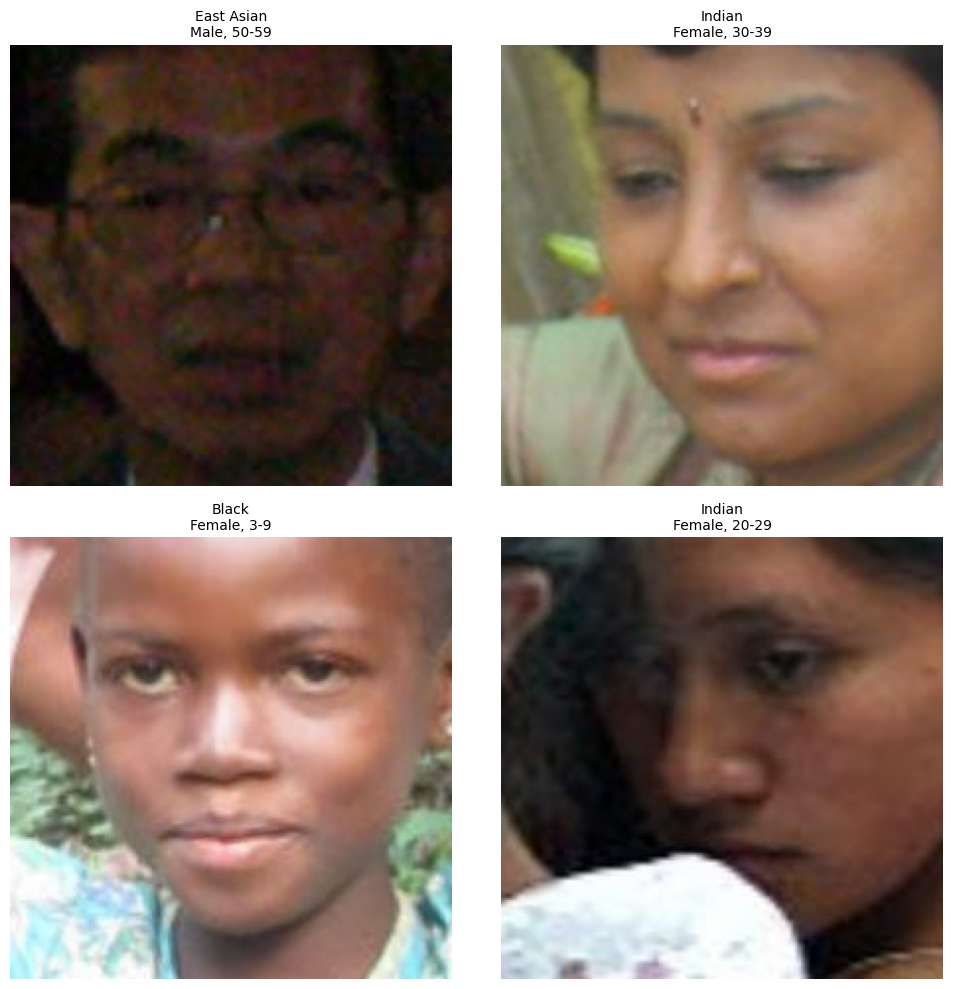

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

path = "/kaggle/input/fairface/FairFace"
labels_dir = "/kaggle/input/fairface/FairFace/train_labels.csv"

# Read in the data
df = pd.read_csv(labels_dir)

# Plot a few examples from the train set
sample = df.head(4)
plt.figure(figsize=(10, 10))

for i, row in sample.iterrows():
    img_path = os.path.join(path, row['file'])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    
    label = f"{row['race']}\n{row['gender']}, {row['age']}"
    plt.title(label, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

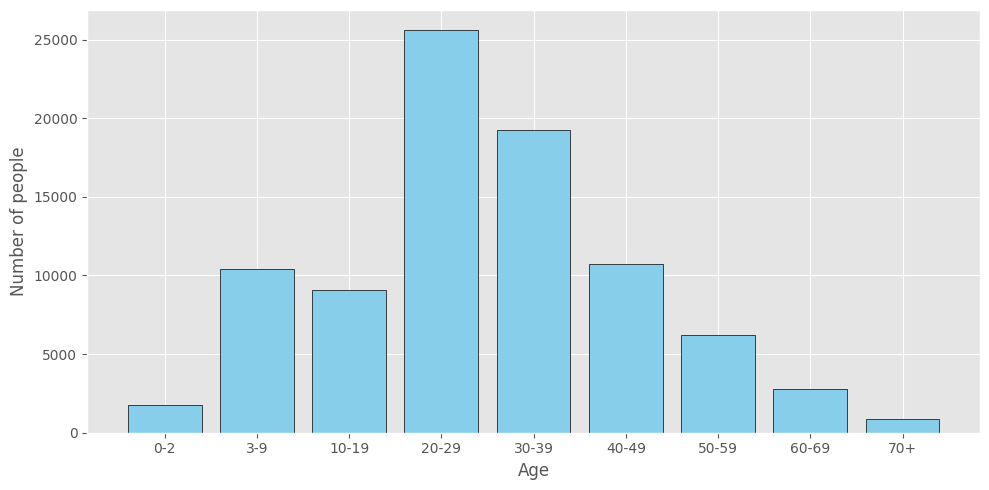

In [2]:
# Plot the distribution of ages in the dataset
age_categories = [
    "0-2", "3-9", "10-19", "20-29", "30-39",
    "40-49", "50-59", "60-69", "more than 70"
]

age_labels = [
    "0-2", "3-9", "10-19", "20-29", "30-39",
    "40-49", "50-59", "60-69", "70+"
]

age_counts = df["age"].value_counts().reindex(age_categories, fill_value=0)

plt.style.use("ggplot")
plt.figure(figsize=(10, 5))
bars = plt.bar(age_labels, age_counts, color="skyblue", edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Number of people")
plt.grid(axis="y", color="white", linestyle="-", linewidth=0.8)
plt.tight_layout()
plt.show()


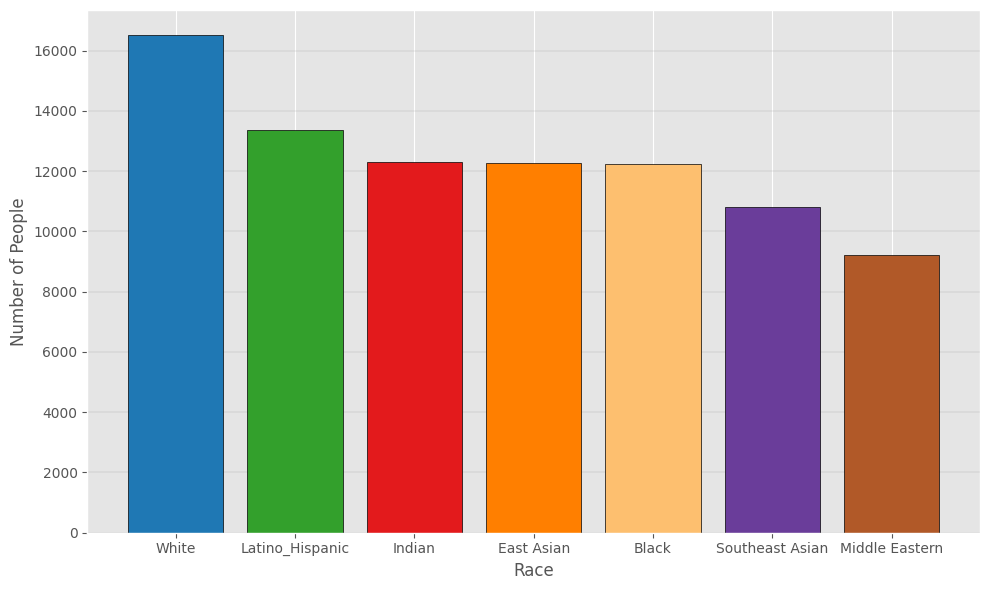

In [3]:
# Plot the distribution of races

race_counts = df["race"].value_counts()
custom_colors = ["#1f78b4", "#33a02c", "#e31a1c", "#ff7f00", "#fdbf6f", "#6a3d9a", "#b15928"]

plt.figure(figsize=(10, 6))
plt.bar(race_counts.index, race_counts, color=custom_colors[:len(race_counts)], edgecolor="black")
plt.xlabel("Race")
plt.ylabel("Number of People")
plt.grid(axis="y", color="gray", linestyle="-", linewidth=0.3, alpha=0.5)
plt.tight_layout()
plt.show()

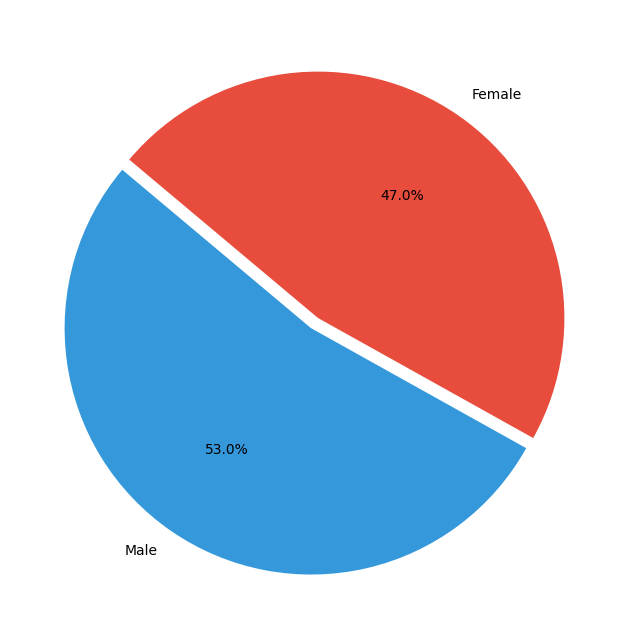

In [4]:
# Plot the distribution of gender

gender_counts = df["gender"].value_counts()
total = gender_counts.sum()
gender_percentages = (gender_counts / total * 100).round(2)

plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
        colors=["#3498db", "#e74c3c"], startangle=140, explode=(0.05, 0))
plt.show()